In [260]:
%pwd

'/content'

In [261]:
!ls -l

total 48
drwx------  3 root root  4096 Oct  6 17:43 drive
drwxr-xr-x  1 root root  4096 Aug 27 16:17 sample_data
drwxr-xr-x  2 root root 36864 Oct  6 13:08 test
drwxr-xr-x 14 root root  4096 Oct  6 11:19 train


In [262]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [0]:
from zipfile import ZipFile

In [0]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [0]:
project_path = "/content/drive/My Drive/CNN/"

In [0]:
#Extracting data from zip file
with ZipFile(project_path+'train.zip', 'r') as zip:
  zip.extractall() 

In [0]:
with ZipFile(project_path+'test.zip', 'r') as zip:
  zip.extractall() 

In [267]:
with ZipFile(project_path+'train.zip', 'r') as zip:
  zip.printdir() 
  # extracting all the files 
  print('Extracting all the files now...') 
  zip.extractall() 
  print('Done!') 
  

File Name                                             Modified             Size
train/                                         2017-11-21 19:11:38            0
train/Fat Hen/                                 2017-11-21 19:27:14            0
train/Fat Hen/5bdfa3a44.png                    2017-11-21 19:20:14       214807
train/Fat Hen/a86b9c0cd.png                    2017-11-21 19:24:00       188575
train/Fat Hen/f3f6559bf.png                    2017-11-21 19:26:46       175787
train/Fat Hen/946b48f62.png                    2017-11-21 19:26:44       271646
train/Fat Hen/4d7fd4020.png                    2017-11-21 19:24:58        96097
train/Fat Hen/2509e5bc5.png                    2017-11-21 19:25:20       202049
train/Fat Hen/e2462573b.png                    2017-11-21 19:15:10        91457
train/Fat Hen/7e98e4aa6.png                    2017-11-21 19:17:46       386753
train/Fat Hen/075cb6666.png                    2017-11-21 19:16:16        21427
train/Fat Hen/b43d0a350.png             

In [59]:
with ZipFile(project_path+'test.zip', 'r') as zip:
  zip.printdir() 
  # extracting all the files 
  print('Extracting all the files now...') 
  zip.extractall() 
  print('Done!') 

File Name                                             Modified             Size
test/                                          2017-11-21 19:27:14            0
test/c0461776c.png                             2017-11-21 19:19:32       163496
test/4bbfd1e05.png                             2017-11-21 19:22:12       161509
test/1d0cbd819.png                             2017-11-21 19:17:24       190282
test/93079d970.png                             2017-11-21 19:15:26       104227
test/856f2910a.png                             2017-11-21 19:25:10       151297
test/976e4e079.png                             2017-11-21 19:15:08        91682
test/b31292706.png                             2017-11-21 19:14:54       129781
test/29bab7cad.png                             2017-11-21 19:26:00       133065
test/37297a64c.png                             2017-11-21 19:14:44       130889
test/f2dc546ca.png                             2017-11-21 19:25:46       101072
test/b6a3f7876.png                      

In [0]:
import cv2
from glob import glob

In [0]:
train_image_path = 'train/*/*.png'
test_image_path = 'test/*/*.png'


In [0]:
images_train = glob(train_image_path)
images_test = glob(test_image_path)

In [0]:
num_train = len(images_train)
num_test = len(images_test)


In [272]:
print(num_train)

4750


In [0]:
trainingset = []
traininglabels = []
SCALE = 70

In [274]:
print(images_train)

['train/Scentless Mayweed/1c0322399.png', 'train/Scentless Mayweed/3c69e3279.png', 'train/Scentless Mayweed/37573d77c.png', 'train/Scentless Mayweed/a0dbc4a62.png', 'train/Scentless Mayweed/2ab910bdf.png', 'train/Scentless Mayweed/d512071bd.png', 'train/Scentless Mayweed/5822cf4d1.png', 'train/Scentless Mayweed/9b40fd5b4.png', 'train/Scentless Mayweed/6a45a19ec.png', 'train/Scentless Mayweed/e3b88c3c0.png', 'train/Scentless Mayweed/9151d1f37.png', 'train/Scentless Mayweed/78d0fe480.png', 'train/Scentless Mayweed/395ff5971.png', 'train/Scentless Mayweed/447b46d12.png', 'train/Scentless Mayweed/82a15579e.png', 'train/Scentless Mayweed/ba1bc108d.png', 'train/Scentless Mayweed/6df9e4b85.png', 'train/Scentless Mayweed/eef749129.png', 'train/Scentless Mayweed/734fc97ac.png', 'train/Scentless Mayweed/bc656f071.png', 'train/Scentless Mayweed/f0fcd1a29.png', 'train/Scentless Mayweed/898a9fd7e.png', 'train/Scentless Mayweed/8842741cb.png', 'train/Scentless Mayweed/da9acbb63.png', 'train/Scentles

In [275]:
#Reading and resizing the image
for i in images_train:
  trainingset.append(cv2.resize(cv2.imread(i),(SCALE,SCALE)))
  traininglabels.append(i.split('/')[-2])
   
    
trainingset = np.asarray(trainingset)
traininglabels = pd.DataFrame(traininglabels)
print(len(trainingset))
print(len(traininglabels))

4750
4750


(194, 194, 3) (70, 70, 3)


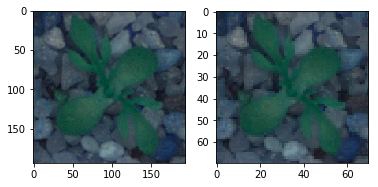

In [276]:
#print a sample image
sample_image_scale = trainingset[1]
sample_image_orig = cv2.imread(images_train[1])
print(sample_image_orig.shape, sample_image_scale.shape)
plt.subplot(1,2,1)
plt.imshow(sample_image_orig)
plt.subplot(1,2,2)
plt.imshow(sample_image_scale)

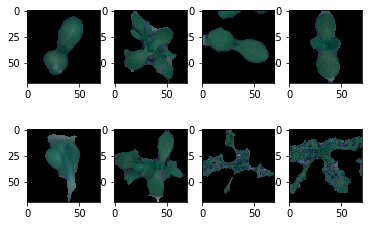

In [277]:
new_train = []

for i in trainingset:
    blurr = cv2.GaussianBlur(i,(5,5),0)
    hsv = cv2.cvtColor(blurr,cv2.COLOR_BGR2HSV)
    lower = (25,40,50)
    upper = (75,255,255)
    mask = cv2.inRange(hsv,lower,upper)
    struc = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(11,11))
    mask = cv2.morphologyEx(mask,cv2.MORPH_CLOSE,struc)
    boolean = mask>0
    new = np.zeros_like(i,np.uint8)
    new[boolean] = i[boolean]
    new_train.append(new)

new_train = np.asarray(new_train)

# NEW IMAGES
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(new_train[i])

In [0]:
from sklearn import preprocessing
from keras.utils import np_utils

In [279]:
labels = preprocessing.LabelEncoder()
labels.fit(traininglabels[0])
print('Classes'+str(labels.classes_))
encodedlabels = labels.transform(traininglabels[0])
clearalllabels = np_utils.to_categorical(encodedlabels)
classes = clearalllabels.shape[1]
print(str(classes))

Classes['Black-grass' 'Charlock' 'Cleavers' 'Common Chickweed' 'Common wheat'
 'Fat Hen' 'Loose Silky-bent' 'Maize' 'Scentless Mayweed'
 'Shepherds Purse' 'Small-flowered Cranesbill' 'Sugar beet']
12


In [0]:
from sklearn.model_selection import train_test_split

In [0]:
#Normalizing training features and spliting data into training and valdation set
new_train = new_train/255
x_train,x_test,y_train,y_test = train_test_split(new_train,clearalllabels,test_size=0.25,
                                                 random_state=10,stratify=clearalllabels)

In [282]:
print('x_train:', x_train.shape)
print('y_train:', y_train.shape)
print('x_train:', x_test.shape)
print('y_train:', y_test.shape)

x_train: (3562, 70, 70, 3)
y_train: (3562, 12)
x_train: (1188, 70, 70, 3)
y_train: (1188, 12)


In [0]:
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout
from keras.layers import Flatten
from keras.layers.convolutional import Conv2D
from keras.layers.convolutional import MaxPooling2D
from keras.layers import BatchNormalization

In [0]:
#Defining a model
EPOCHS=50
BATCH_SIZE=75

model = Sequential()
model.add(Conv2D(filters=32, kernel_size=(3, 3), input_shape=(SCALE, SCALE, 3), activation='relu'))
model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(BatchNormalization(axis=3))
model.add(Dropout(0.1))
model.add(Flatten())
model.add(Dense(classes, activation='softmax'))


In [0]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [286]:
model.fit(x_train, y_train, batch_size=BATCH_SIZE, nb_epoch=EPOCHS, validation_data=(x_test, y_test))

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:1: UserWarning: The `nb_epoch` argument in `fit` has been renamed `epochs`.
  """Entry point for launching an IPython kernel.


Train on 3562 samples, validate on 1188 samples
Epoch 1/50
3562/3562 [==============================] - 9s 3ms/step - loss: 1.5462 - acc: 0.5163 - val_loss: 2.4371 - val_acc: 0.4891
Epoch 2/50
3562/3562 [==============================] - 7s 2ms/step - loss: 0.6325 - acc: 0.7979 - val_loss: 3.8505 - val_acc: 0.3468
Epoch 3/50
3562/3562 [==============================] - 7s 2ms/step - loss: 0.2859 - acc: 0.9124 - val_loss: 2.8794 - val_acc: 0.4848
Epoch 4/50
3562/3562 [==============================] - 7s 2ms/step - loss: 0.1579 - acc: 0.9559 - val_loss: 2.5114 - val_acc: 0.5614
Epoch 5/50
3562/3562 [==============================] - 7s 2ms/step - loss: 0.0748 - acc: 0.9778 - val_loss: 4.9518 - val_acc: 0.3796
Epoch 6/50
3562/3562 [==============================] - 7s 2ms/step - loss: 0.0358 - acc: 0.9935 - val_loss: 4.0486 - val_acc: 0.4428
Epoch 7/50
3562/3562 [==============================] - 7s 2ms/step - loss: 0.0355 - acc: 0.9933 - val_loss: 3.0657 - val_acc: 0.5648
Epoch 8/50
356

In [0]:
#Defining a same type of model, but this time running with SGD optimizer instead of adam.
EPOCHS=50
BATCH_SIZE=75

model1 = Sequential()
model1.add(Conv2D(filters=32, kernel_size=(3, 3), input_shape=(SCALE, SCALE, 3), activation='relu'))
model1.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model1.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu'))
model1.add(MaxPooling2D((2, 2)))
model1.add(BatchNormalization(axis=3))
model1.add(Dropout(0.1))
model1.add(Flatten())
model1.add(Dense(classes, activation='softmax'))

In [0]:
model1.compile(loss='categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])

In [289]:
model1.fit(x_train, y_train, batch_size=BATCH_SIZE, nb_epoch=EPOCHS, validation_data=(x_test, y_test))

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:1: UserWarning: The `nb_epoch` argument in `fit` has been renamed `epochs`.
  """Entry point for launching an IPython kernel.


Train on 3562 samples, validate on 1188 samples
Epoch 1/50
3562/3562 [==============================] - 9s 3ms/step - loss: 1.6924 - acc: 0.4554 - val_loss: 1.6534 - val_acc: 0.4646
Epoch 2/50
3562/3562 [==============================] - 7s 2ms/step - loss: 1.0444 - acc: 0.6558 - val_loss: 2.7258 - val_acc: 0.3923
Epoch 3/50
3562/3562 [==============================] - 7s 2ms/step - loss: 0.7029 - acc: 0.7774 - val_loss: 4.2147 - val_acc: 0.2820
Epoch 4/50
3562/3562 [==============================] - 7s 2ms/step - loss: 0.4807 - acc: 0.8571 - val_loss: 5.6158 - val_acc: 0.2146
Epoch 5/50
3562/3562 [==============================] - 7s 2ms/step - loss: 0.3282 - acc: 0.9076 - val_loss: 1.5138 - val_acc: 0.5884
Epoch 6/50
3562/3562 [==============================] - 7s 2ms/step - loss: 0.2249 - acc: 0.9467 - val_loss: 2.8352 - val_acc: 0.4705
Epoch 7/50
3562/3562 [==============================] - 7s 2ms/step - loss: 0.1470 - acc: 0.9691 - val_loss: 2.4235 - val_acc: 0.5210
Epoch 8/50
356

In [0]:
#Training accuracy is very high in both the models. But validation accuracy is not upto the training accuracy. 
#SGD gave better validation accuracy as compared to adam. 
#We can conclude that both the models are overfitting
#Lets use image augmentation methods to generate different images and check the accuracy. 

In [0]:
import tensorflow as tf
from keras.preprocessing.image import ImageDataGenerator


In [0]:
img_generator= tf.keras.preprocessing.image.ImageDataGenerator(rotation_range=20,
                                                                   width_shift_range=0.2,
                                                                   height_shift_range=0.2,
                                                                   horizontal_flip=True,
                                                                   vertical_flip=True,
                                                                   shear_range=0.2,
                                                                   zoom_range=0.3)

In [0]:
img_generator.fit(x_train)

In [294]:
model.fit_generator(img_generator.flow(x_train, y_train, batch_size=BATCH_SIZE), steps_per_epoch=len(x_train) / BATCH_SIZE, 
                    epochs=EPOCHS, validation_data=(x_test, y_test))


Epoch 1/50
48/47 [==============================] - 8s 170ms/step - loss: 3.0276 - acc: 0.3634 - val_loss: 15.1374 - val_acc: 0.0606
Epoch 2/50
48/47 [==============================] - 8s 158ms/step - loss: 1.5531 - acc: 0.4751 - val_loss: 14.4007 - val_acc: 0.0606
Epoch 3/50
48/47 [==============================] - 8s 157ms/step - loss: 1.3811 - acc: 0.5279 - val_loss: 14.6511 - val_acc: 0.0606
Epoch 4/50
48/47 [==============================] - 8s 161ms/step - loss: 1.2912 - acc: 0.5713 - val_loss: 12.7084 - val_acc: 0.0657
Epoch 5/50
48/47 [==============================] - 8s 159ms/step - loss: 1.2830 - acc: 0.5752 - val_loss: 11.5850 - val_acc: 0.0724
Epoch 6/50
48/47 [==============================] - 8s 158ms/step - loss: 1.2246 - acc: 0.6018 - val_loss: 12.1237 - val_acc: 0.1364
Epoch 7/50
48/47 [==============================] - 8s 159ms/step - loss: 1.2023 - acc: 0.6124 - val_loss: 7.0517 - val_acc: 0.1044
Epoch 8/50
48/47 [==============================] - 8s 162ms/step - lo

In [0]:
#Accuracy level decreased significantly after image augmentation. This is quite surprising. 
#Lets build a model with more conv layers and check the accuracy. 

In [0]:
model2 = Sequential()

model2.add(Conv2D(filters=32, kernel_size=(3, 3), input_shape=(SCALE, SCALE, 3), activation='relu'))
model2.add(BatchNormalization(axis=3))
model2.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu'))
model2.add(MaxPooling2D((2, 2)))
model2.add(BatchNormalization(axis=3))
model2.add(Dropout(0.1))

model2.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model2.add(BatchNormalization(axis=3))
model2.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model2.add(MaxPooling2D((2, 2)))
model2.add(BatchNormalization(axis=3))
model2.add(Dropout(0.1))

model2.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu'))
model2.add(BatchNormalization(axis=3))
model2.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu'))
model2.add(MaxPooling2D((2, 2)))
model2.add(BatchNormalization(axis=3))
model2.add(Dropout(0.1))

model2.add(Flatten())

model2.add(Dense(128, activation='relu'))
model2.add(BatchNormalization())
model2.add(Dropout(0.5))

model2.add(Dense(128, activation='relu'))
model2.add(BatchNormalization())
model2.add(Dropout(0.5))

model2.add(Dense(classes, activation='softmax'))

model2.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [0]:
#Defining call back parameters to select best results. 
es = tf.keras.callbacks.EarlyStopping(monitor='val_acc',patience=5)

In [298]:
model2.fit_generator(img_generator.flow(x_train, y_train, batch_size=BATCH_SIZE), steps_per_epoch=len(x_train) / BATCH_SIZE, 
                    epochs=EPOCHS, validation_data=(x_test, y_test),callbacks=[es])

Epoch 1/50
48/47 [==============================] - 12s 242ms/step - loss: 2.9016 - acc: 0.2070 - val_loss: 3.3121 - val_acc: 0.2273
Epoch 2/50
48/47 [==============================] - 7s 140ms/step - loss: 2.1202 - acc: 0.3295 - val_loss: 1.7611 - val_acc: 0.4352
Epoch 3/50
48/47 [==============================] - 7s 149ms/step - loss: 1.8333 - acc: 0.3832 - val_loss: 2.2633 - val_acc: 0.3375
Epoch 4/50
48/47 [==============================] - 7s 149ms/step - loss: 1.6568 - acc: 0.4379 - val_loss: 1.4774 - val_acc: 0.5589
Epoch 5/50
48/47 [==============================] - 7s 149ms/step - loss: 1.5372 - acc: 0.4698 - val_loss: 4.0345 - val_acc: 0.3981
Epoch 6/50
48/47 [==============================] - 7s 150ms/step - loss: 1.4172 - acc: 0.4974 - val_loss: 1.5027 - val_acc: 0.5564
Epoch 7/50
48/47 [==============================] - 7s 149ms/step - loss: 1.3453 - acc: 0.5490 - val_loss: 1.4612 - val_acc: 0.5960
Epoch 8/50
48/47 [==============================] - 7s 148ms/step - loss: 1

In [0]:
model2.compile(loss='categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])

In [300]:
model2.fit_generator(img_generator.flow(x_train, y_train, batch_size=BATCH_SIZE), steps_per_epoch=len(x_train) / BATCH_SIZE, 
                    epochs=EPOCHS, validation_data=(x_test, y_test),callbacks=[es])

Epoch 1/50
48/47 [==============================] - 11s 224ms/step - loss: 0.7235 - acc: 0.7574 - val_loss: 3.0416 - val_acc: 0.2054
Epoch 2/50
48/47 [==============================] - 7s 136ms/step - loss: 0.6911 - acc: 0.7738 - val_loss: 1.8603 - val_acc: 0.4613
Epoch 3/50
48/47 [==============================] - 7s 143ms/step - loss: 0.6792 - acc: 0.7735 - val_loss: 2.0767 - val_acc: 0.4108
Epoch 4/50
48/47 [==============================] - 7s 144ms/step - loss: 0.6572 - acc: 0.7858 - val_loss: 5.0258 - val_acc: 0.3510
Epoch 5/50
48/47 [==============================] - 7s 145ms/step - loss: 0.6558 - acc: 0.7785 - val_loss: 1.2354 - val_acc: 0.6246
Epoch 6/50
48/47 [==============================] - 7s 142ms/step - loss: 0.6520 - acc: 0.7747 - val_loss: 1.1544 - val_acc: 0.5774
Epoch 7/50
48/47 [==============================] - 7s 144ms/step - loss: 0.6566 - acc: 0.7797 - val_loss: 0.7108 - val_acc: 0.7542
Epoch 8/50
48/47 [==============================] - 7s 144ms/step - loss: 0

In [303]:
print(model2.evaluate(x_train, y_train)) 

3562/3562 [==============================] - 2s 575us/step
[0.7430885480335092, 0.7001684446270582]


In [304]:
print(model2.evaluate(x_test, y_test))

1188/1188 [==============================] - 1s 535us/step
[0.7915471675821426, 0.6826599326599326]


In [0]:
#I was not able to read the test file. After reading the test file we can apply the same steps and can check the result. 